In [1]:
# =========================
# 0. Dependencies
# =========================
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 64.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)

In [3]:
# =========================
# 2. Load + Combine Data
# =========================
df_me = pd.read_csv("/content/reviews_me.csv")
df_sib1 = pd.read_csv("/content/reviews_sibling1.csv")
df_sib2 = pd.read_csv("/content/reviews_sibling2.csv")

cols = ["Name", "Year", "Rating", "Review"]

df_me = df_me[cols]
df_sib1 = df_sib1[cols]
df_sib2 = df_sib2[cols]

rename_map = {
    "Name": "movie_title",
    "Year": "year",
    "Rating": "star_rating",
    "Review": "review_text"
}

df_me = df_me.rename(columns=rename_map)
df_sib1 = df_sib1.rename(columns=rename_map)
df_sib2 = df_sib2.rename(columns=rename_map)

df_me["source"] = "you"
df_sib1["source"] = "sibling"
df_sib2["source"] = "sibling"

df = pd.concat([df_me, df_sib1, df_sib2], ignore_index=True)

df = df.dropna(subset=["review_text", "star_rating"])
df = df[df["review_text"].str.strip() != ""]

print("Total dataset size:", len(df))

Total dataset size: 1058


In [4]:
# =========================
# 3. Map Ratings → Labels
# =========================
def map_sentiment(r):
    if r >= 3.5:
        return 2  # positive
    elif r >= 2.5:
        return 1  # neutral
    else:
        return 0  # negative

df["label"] = df["star_rating"].apply(map_sentiment)

In [5]:
# =========================
# 4. Year Buckets (for later)
# =========================
def year_bucket(y):
    if y < 1990:
        return "Pre-1990"
    elif y < 2010:
        return "1990-2009"
    else:
        return "2010+"

df["year_group"] = df["year"].apply(year_bucket)

In [6]:
# =========================
# 5. Train/Test Split
# =========================
train_df, test_df = train_test_split(
    df[["movie_title", "review_text", "label", "source", "year_group"]],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [7]:
# =========================
# 6. BASELINE MODEL
# =========================
print("\n--- Baseline Model ---")

baseline_model = pipeline("sentiment-analysis")

def convert_label(output):
    if output["label"] == "POSITIVE":
        return 2
    else:
        return 0

baseline_preds = baseline_model(list(test_df["review_text"]))
baseline_preds = [convert_label(p) for p in baseline_preds]

test_df = test_df.reset_index(drop=True)
test_df["baseline_pred"] = baseline_preds

print("\nBaseline Accuracy:",
      accuracy_score(test_df["label"], baseline_preds))

print("\nBaseline Report:")
print(classification_report(test_df["label"], baseline_preds))

# =========================
# Baseline by Source
# =========================
print("\n--- Baseline Accuracy by Source ---")
for group in test_df["source"].unique():
    subset = test_df[test_df["source"] == group]
    acc = accuracy_score(subset["label"], subset["baseline_pred"])
    print(f"{group}: {acc:.3f}")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.



--- Baseline Model ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


Baseline Accuracy: 0.6367924528301887

Baseline Report:
              precision    recall  f1-score   support

           0       0.11      0.80      0.20        10
           1       0.00      0.00      0.00        24
           2       0.91      0.71      0.80       178

    accuracy                           0.64       212
   macro avg       0.34      0.50      0.33       212
weighted avg       0.77      0.64      0.68       212


--- Baseline Accuracy by Source ---
sibling: 0.491
you: 0.800


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
# =========================
# 6B. IMDB BASELINE MODEL
# =========================
print("\n--- IMDB Baseline Model ---")

imdb_model = pipeline(
    "sentiment-analysis",
    model="textattack/bert-base-uncased-imdb"
)

imdb_preds = imdb_model(list(test_df["review_text"]))

def convert_label_imdb(output):
    if output["label"] == "LABEL_1":
        return 2
    else:
        return 0  # still binary

imdb_preds = [convert_label_imdb(p) for p in imdb_preds]

test_df["imdb_pred"] = imdb_preds

# Overall accuracy
print("\nIMDB Baseline Accuracy:",
      accuracy_score(test_df["label"], imdb_preds))

print("\nIMDB Classification Report:")
print(classification_report(test_df["label"], imdb_preds))

# =========================
# IMDB Accuracy by Source
# =========================
print("\n--- IMDB Accuracy by Source ---")

for group in test_df["source"].unique():
    subset = test_df[test_df["source"] == group]
    acc = accuracy_score(subset["label"], subset["imdb_pred"])
    print(f"{group}: {acc:.3f}")


--- IMDB Baseline Model ---


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


IMDB Baseline Accuracy: 0.6226415094339622

IMDB Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.70      0.17        10
           1       0.00      0.00      0.00        24
           2       0.91      0.70      0.79       178

    accuracy                           0.62       212
   macro avg       0.33      0.47      0.32       212
weighted avg       0.76      0.62      0.67       212


--- IMDB Accuracy by Source ---
sibling: 0.509
you: 0.750


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
# =========================
# 7. HuggingFace Dataset
# =========================
train_dataset = Dataset.from_pandas(train_df[["review_text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["review_text", "label"]])

In [12]:
# =========================
# 8. Tokenization
# =========================
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["review_text"], truncation=True, padding=True)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset = train_dataset.remove_columns(["review_text"])
test_dataset = test_dataset.remove_columns(["review_text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/846 [00:00<?, ? examples/s]

Map:   0%|          | 0/212 [00:00<?, ? examples/s]

In [13]:
# =========================
# 9. Model
# =========================
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
# =========================
# 10. Training Setup
# =========================
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="no",
    logging_dir="./logs"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [15]:
# =========================
# 11. Train
# =========================
print("\n--- Training ---")
trainer.train()


--- Training ---


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.546749,0.839623
2,No log,0.522265,0.844340
3,No log,0.396873,0.858491


TrainOutput(global_step=318, training_loss=0.4650021439078469, metrics={'train_runtime': 125.7207, 'train_samples_per_second': 20.188, 'train_steps_per_second': 2.529, 'total_flos': 336208253478912.0, 'train_loss': 0.4650021439078469, 'epoch': 3.0})

In [16]:
# =========================
# 12. Evaluate
# =========================
print("\n--- Finetuned Model ---")

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

test_df["finetuned_pred"] = preds

print("\nFinetuned Accuracy:",
      accuracy_score(test_df["label"], preds))

print("\nFinetuned Report:")
print(classification_report(test_df["label"], preds))

# =========================
# Finetuned by Source
# =========================
print("\n--- Finetuned Accuracy by Source ---")
for group in test_df["source"].unique():
    subset = test_df[test_df["source"] == group]
    acc = accuracy_score(subset["label"], subset["finetuned_pred"])
    print(f"{group}: {acc:.3f}")


--- Finetuned Model ---



Finetuned Accuracy: 0.8584905660377359

Finetuned Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.50      0.33      0.40        24
           2       0.89      0.98      0.93       178

    accuracy                           0.86       212
   macro avg       0.46      0.44      0.44       212
weighted avg       0.80      0.86      0.83       212


--- Finetuned Accuracy by Source ---
sibling: 0.848
you: 0.870


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


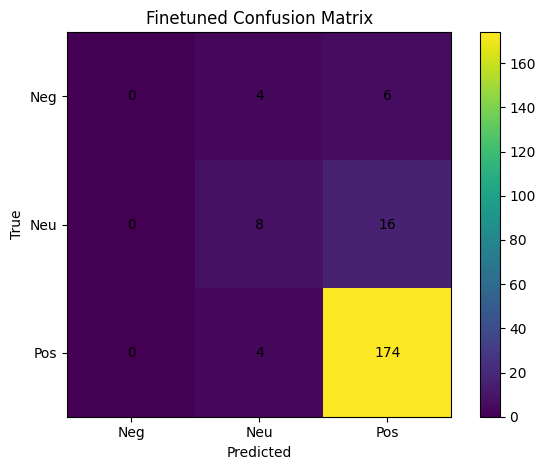

In [17]:
# =========================
# 13. Confusion Matrix Plot
# =========================
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    labels = ["Neg", "Neu", "Pos"]
    ticks = np.arange(len(labels))

    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j],
                     ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    test_df["label"],
    test_df["finetuned_pred"],
    "Finetuned Confusion Matrix"
)

In [18]:
# =========================
# 14. Error Analysis
# =========================
print("\n--- Sample Sibling Errors ---")

for i in range(len(test_df)):
    if (test_df.loc[i, "source"] == "sibling" and
        test_df.loc[i, "label"] != test_df.loc[i, "finetuned_pred"]):

        print("\n---")
        print("Movie:", test_df.loc[i, "movie_title"])
        print("Review:", test_df.loc[i, "review_text"])
        print("True:", test_df.loc[i, "label"])
        print("Pred:", test_df.loc[i, "finetuned_pred"])


--- Sample Sibling Errors ---

---
Movie: Home Sweet Home Alone
Review: the main character was insufferable and the villains were humanized, meaning their inevitable torture in the defense of the house wasn’t cathartic. the pacing is terrible and the main kid has no screen time.
True: 0
Pred: 1

---
Movie: Kingsman: The Golden Circle
Review: can't believe elton john played both eggsy AND himself that's what i call range
True: 1
Pred: 2

---
Movie: Pokémon the Movie: I Choose You!
Review: marshadow is the best character in this movie and every pokémon movie. so annoyed with the dude with the bad hair and incineroar that he tries to murder everyone. also the dude with the lucario and the dead luxray was cool i guess
True: 0
Pred: 2

---
Movie: Jurassic World Dominion
Review: i really liked this movie! i was SO tired this morning and i finally got a chance to take a nap! thank you chris pratt!
True: 0
Pred: 2

---
Movie: Red Dawn
Review: danny looks like greg heffley 10 years later
True:


--- Review Distribution by Year Group ---
source      sibling  you
year_group              
1990-2009       151  104
2010+           334  202
Pre-1990         52  215

--- Proportion by Year Group ---
source       sibling       you
year_group                    
1990-2009   0.592157  0.407843
2010+       0.623134  0.376866
Pre-1990    0.194757  0.805243


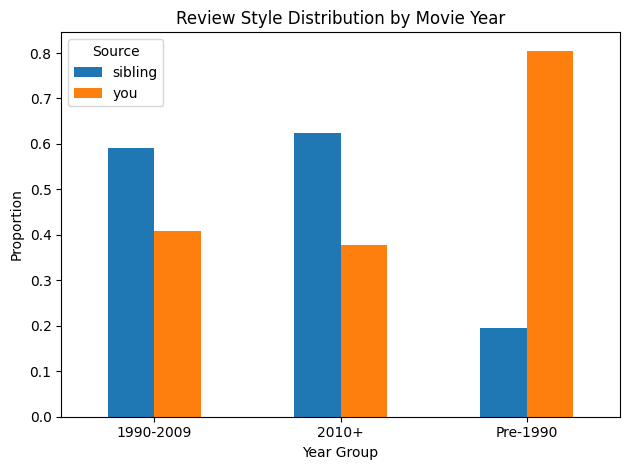

In [19]:
# =========================
# 15. Year-Based Analysis
# =========================
print("\n--- Review Distribution by Year Group ---")

group_counts = df.groupby(["year_group", "source"]).size().unstack(fill_value=0)
print(group_counts)

print("\n--- Proportion by Year Group ---")

group_props = group_counts.div(group_counts.sum(axis=1), axis=0)
print(group_props)

group_props.plot(kind="bar")

plt.title("Review Style Distribution by Movie Year")
plt.xlabel("Year Group")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Source")

plt.tight_layout()
plt.show()

In [20]:
# =========================
# 16. Accuracy by Year Group
# =========================
print("\n--- Accuracy by Year Group (Finetuned) ---")

for group in test_df["year_group"].unique():
    subset = test_df[test_df["year_group"] == group]
    acc = accuracy_score(subset["label"], subset["finetuned_pred"])
    print(f"{group}: {acc:.3f}")


--- Accuracy by Year Group (Finetuned) ---
1990-2009: 0.906
2010+: 0.798
Pre-1990: 0.927


In [21]:
# =========================
# 17. Model Comparison Summary
# =========================
print("\n=== MODEL COMPARISON ===")

models = ["baseline_pred", "imdb_pred", "finetuned_pred"]

for model_name in models:
    print(f"\n--- {model_name} ---")

    overall = accuracy_score(test_df["label"], test_df[model_name])
    print(f"Overall Accuracy: {overall:.3f}")

    for group in test_df["source"].unique():
        subset = test_df[test_df["source"] == group]
        acc = accuracy_score(subset["label"], subset[model_name])
        print(f"{group}: {acc:.3f}")


=== MODEL COMPARISON ===

--- baseline_pred ---
Overall Accuracy: 0.637
sibling: 0.491
you: 0.800

--- imdb_pred ---
Overall Accuracy: 0.623
sibling: 0.509
you: 0.750

--- finetuned_pred ---
Overall Accuracy: 0.858
sibling: 0.848
you: 0.870
